# Fetch the data

In [1]:
import tempfile
from pathlib import Path

import harpy as hp
from spatialdata import read_zarr

tmp = tempfile.TemporaryDirectory(prefix="macsima_")
output_dir = Path(tmp.name)

path = None

sdata = hp.datasets.macsima_colorectal_carcinoma_course(
    checkpoint="checkpoint_2",
    path=path,
)

sdata.write(output_dir / "sdata.zarr", overwrite=True)

sdata = read_zarr(sdata.path)

WARNING  Module 'bioio' is not installed. Install it with `pip install bioio` to use `harpy.io.macsima`.           
WARNING  Module 'bioio-ome-tiff' is not installed. Install it with `pip install bioio-ome-tiff` to use             
         `harpy.io.macsima`.                                                                                       


no parent found for <ome_zarr.reader.Label object at 0x127dd5e20>: None
no parent found for <ome_zarr.reader.Label object at 0x127f208f0>: None
no parent found for <ome_zarr.reader.Label object at 0x127f20d10>: None
no parent found for <ome_zarr.reader.Label object at 0x127f22db0>: None
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-

In [2]:
sdata.path

PosixPath('/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/macsima_d09_ltg8/sdata.zarr')

In [3]:
sdata["table_cells_z_scored_filterd"]

AnnData object with n_obs × n_vars = 3114 × 49
    obs: 'cell_ID', 'fov_labels', 'perimeter', 'eccentricity', 'convex_area', 'area', 'filter_on_size', 'has_nucleus', 'leiden', 'shapeSize'
    var: 'mean', 'std'
    uns: 'umap', 'spatialdata_attrs', 'leiden_colors', 'leiden_weighted_intensity', 'neighbors', 'leiden', 'rank_genes_groups'
    obsm: 'X_umap', 'spatial'
    layers: 'mean_counts'
    obsp: 'connectivities', 'distances'

## Supervised Object classification

In this section, we will use `napari-harpy` to extract object-level features from selected protein channels and train an object classifier.

First, run the cell above to open the napari-harpy interface:

```python
from napari_harpy import Interactive

Interactive(sdata)
```

### Feature extraction

In the **Feature Extraction** widget, use the following settings:

1. Under **Coordinate systems**, select `global_1`.
2. Set **Labels element** to `labels_cells_instanseg`.
3. Set **Image** to `REAscreen_IO_CRC`.
4. Under **Channels**, select `CD3` and `CD8a`.
5. Under **Intensity Features**, select `mean` and `var`.
6. Under **Morphology Features** select `area`.
7. Under **Table**, select `table_cells_z_scored_filterd`.
8. Set **Feature matrix key** to `features_cd3_cd8a`.
9. Click **Calculate**.

This writes the extracted features to the selected table as `.obsm["features_cd3_cd8a"]`, with feature metadata stored under `.uns["feature_matrices"]`.

The same widget also supports multi-sample workflows. Instead of selecting only `global_1`, you can select multiple coordinate systems and calculate the same feature matrix for the matching labels and tables across samples.

### Object classifier

In the **Object Classification** widget, use the following settings:

1. Set **Coordinate system** to `global_1`.
2. Set **Labels element** to `labels_cells_instanseg`.
3. Set **Table** to `table_cells_z_scored_filterd`.
4. Set **Feature matrix** to `features_cd3_cd8a`.

You can now start annotating objects. Select a cell in the labels layer, choose a **User class**, and click **Add (A)** to assign that class. For this exercise, use class `1` for positive cells and class `2` for negative cells. Use **Remove (R)** to clear an annotation from the selected object.

The object classifier can also be used across multiple samples. Use **Training scope** to decide which annotated objects are used for training, and **Prediction scope** to decide where the trained classifier should write predictions.

After adding examples for at least two classes, click **Train Classifier** to generate predictions. When you are satisfied with the annotations and predictions, click **Write Table State** to save the table state back to the backed SpatialData store. Finally, click **Export Classifier** to save the trained classifier for reuse.



In [ ]:
from napari_harpy import Interactive

Interactive(sdata)

2026-05-28 12:44:33.358 | INFO     | harpy.table._add_feature_matrix:_prepare_raster_arrays:665 - Image and labels have different chunk sizes; rechunking labels to match the image's spatial chunks (1, 1024, 1024) for aggregation.
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning

In [7]:
sdata["table_cells_z_scored_filterd"].uns["feature_matrices"]

{'features_cd3_cd8a': {'feature_columns': ['mean__CD8a',
   'mean__CD3',
   'var__CD8a',
   'var__CD3',
   'area'],
  'schema_version': 1,
  'backend': 'numpy',
  'dtype': 'float64',
  'source_label': ['labels_cells_instanseg'],
  'source_image': ['REAscreen_IO_CRC'],
  'source_channels': ['CD8a', 'CD3'],
  'coordinate_system': ['global_1'],
  'features': ['mean', 'var', 'area']}}

In [8]:
sdata["table_cells_z_scored_filterd"].obsm["features_cd3_cd8a"].shape

(3114, 5)

In [9]:
sdata["table_cells_z_scored_filterd"].uns["classifier_config"]

{'model_type': 'RandomForestClassifier',
 'feature_key': 'features_cd3_cd8a',
 'table_name': 'table_cells_z_scored_filterd',
 'roi_mode': 'none',
 'trained': True,
 'eligible': True,
 'reason': 'Ready to train.',
 'training_timestamp': '2026-05-28T06:35:44.156715+00:00',
 'n_labeled_objects': 22,
 'n_features': 5,
 'class_labels_seen': [1, 2],
 'rf_params': {'n_estimators': 100, 'random_state': 0, 'n_jobs': -2},
 'training_scope': 'all',
 'training_regions': ['labels_cells_instanseg'],
 'n_training_rows': 3114,
 'prediction_scope': 'selected_segmentation_only',
 'prediction_regions': ['labels_cells_instanseg'],
 'n_predicted_rows': 3114}

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 auto

### Headless mode

After training a classifier in the **Object Classification** widget, you can click **Export Classifier** to save it as a `.harpy-classifier.joblib` file. This exported classifier can then be reused without opening napari.

For scripted or batch workflows, use the public `napari_harpy.headless` module. This is different from `Interactive(sdata, headless=True)`, which only initializes the napari-harpy widgets without starting the napari event loop. For applying classifiers in a pipeline, use `napari_harpy.headless`.

If the target table already contains a compatible feature matrix, apply the classifier directly:

```python
from napari_harpy import headless

result = headless.apply_classifier_from_path(
    sdata,
    "classifier.harpy-classifier.joblib",
    table_name="table_cells_z_scored_filterd",
    feature_key="features_cd3_cd8a",
)
```

This writes the predictions to the selected table:

```python
sdata["table_cells_z_scored_filterd"].obs["pred_class"]
sdata["table_cells_z_scored_filterd"].obs["pred_confidence"]
```

It also stores apply metadata in `.uns["classifier_apply_config"]`, including the classifier path, feature key, prediction regions, and number of predicted rows.

If the feature matrix does not exist yet, headless mode can first calculate the required features and then apply the classifier:

```python
from napari_harpy import headless

result = headless.apply_classifier_with_feature_extraction_from_path(
    sdata,
    "classifier.harpy-classifier.joblib",
    table_name="table_cells_z_scored_filterd",
    labels_name="labels_cells_instanseg",
    coordinate_system="global_1",
    image_name="REAscreen_IO_CRC",
    feature_key="features_cd3_cd8a",
    overwrite_feature_key=True,
)
```

In this second workflow, you do not pass `mean` and `var` again. The exported classifier already stores the feature schema that was used during training, and headless mode uses that schema to calculate a matching feature matrix.

Headless mode also supports multi-sample workflows. Pass matching lists for labels, coordinate systems, and images to apply the same classifier across several regions of a shared table:

```python
result = headless.apply_classifier_with_feature_extraction_from_path(
    sdata,
    "classifier.harpy-classifier.joblib",
    table_name="table_cells_z_scored_filterd",
    labels_name=["sample_1_cells", "sample_2_cells"],
    coordinate_system=["sample_1", "sample_2"],
    image_name=["sample_1_image", "sample_2_image"],
    feature_key="features_cd3_cd8a",
    overwrite_feature_key=True,
)
```

The returned `result` summarizes how many rows were predicted and how many rows were skipped because of invalid feature values.

The predictions and apply metadata are always written to the in-memory table. If `sdata` is backed by zarr (as here, opened with `read_zarr`), they are also persisted to disk automatically. For an in-memory-only `sdata`, write it yourself with `sdata.write("output.zarr")`.


In [3]:
# test this out

from napari_harpy import headless

result = headless.apply_classifier_with_feature_extraction_from_path(
    sdata,
    "/Users/arne.defauw/VIB/DATA/summer_school_2026/table_cells_z_scored_filterd_features_cd3_cd8a.harpy-classifier.joblib",  # change this to the path where YOU saved the classifier
    table_name="table_cells_z_scored_filterd",
    labels_name="labels_cells_instanseg",
    coordinate_system="global_1",
    image_name="REAscreen_IO_CRC",
    feature_key="features_cd3_cd8a",
    overwrite_feature_key=True,
)

2026-05-28 12:45:16.437 | INFO     | harpy.table._add_feature_matrix:_prepare_raster_arrays:665 - Image and labels have different chunk sizes; rechunking labels to match the image's spatial chunks (1, 1024, 1024) for aggregation.
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning

In [4]:
sdata["table_cells_z_scored_filterd"].obs["pred_class"]

cells
105_labels_cells_instanseg_a57cae0b     2
133_labels_cells_instanseg_a57cae0b     2
141_labels_cells_instanseg_a57cae0b     2
145_labels_cells_instanseg_a57cae0b     2
149_labels_cells_instanseg_a57cae0b     2
                                       ..
6377_labels_cells_instanseg_a57cae0b    1
6381_labels_cells_instanseg_a57cae0b    2
6385_labels_cells_instanseg_a57cae0b    1
6392_labels_cells_instanseg_a57cae0b    2
6402_labels_cells_instanseg_a57cae0b    1
Name: pred_class, Length: 3114, dtype: category
Categories (3, int64): [0, 1, 2]

In [7]:
sdata["table_cells_z_scored_filterd"].uns["classifier_apply_config"]

{'applied': True,
 'apply_timestamp': '2026-05-28T10:45:17.139066+00:00',
 'classifier_path': '/Users/arne.defauw/VIB/DATA/summer_school_2026/table_cells_z_scored_filterd_features_cd3_cd8a.harpy-classifier.joblib',
 'source_classifier_config': {'model_type': 'RandomForestClassifier',
  'feature_key': 'features_cd3_cd8a',
  'table_name': 'table_cells_z_scored_filterd',
  'roi_mode': 'none',
  'trained': True,
  'eligible': True,
  'reason': 'Ready to train.',
  'training_timestamp': '2026-05-27T10:16:34.458288+00:00',
  'n_labeled_objects': 48,
  'n_features': 5,
  'class_labels_seen': [1, 2],
  'rf_params': {'n_estimators': 100, 'random_state': 0, 'n_jobs': -2},
  'training_scope': 'all',
  'training_regions': ['labels_cells_instanseg'],
  'n_training_rows': 3114,
  'prediction_scope': 'selected_segmentation_only',
  'prediction_regions': ['labels_cells_instanseg'],
  'n_predicted_rows': 3114},
 'table_name': 'table_cells_z_scored_filterd',
 'feature_key': 'features_cd3_cd8a',
 'predic

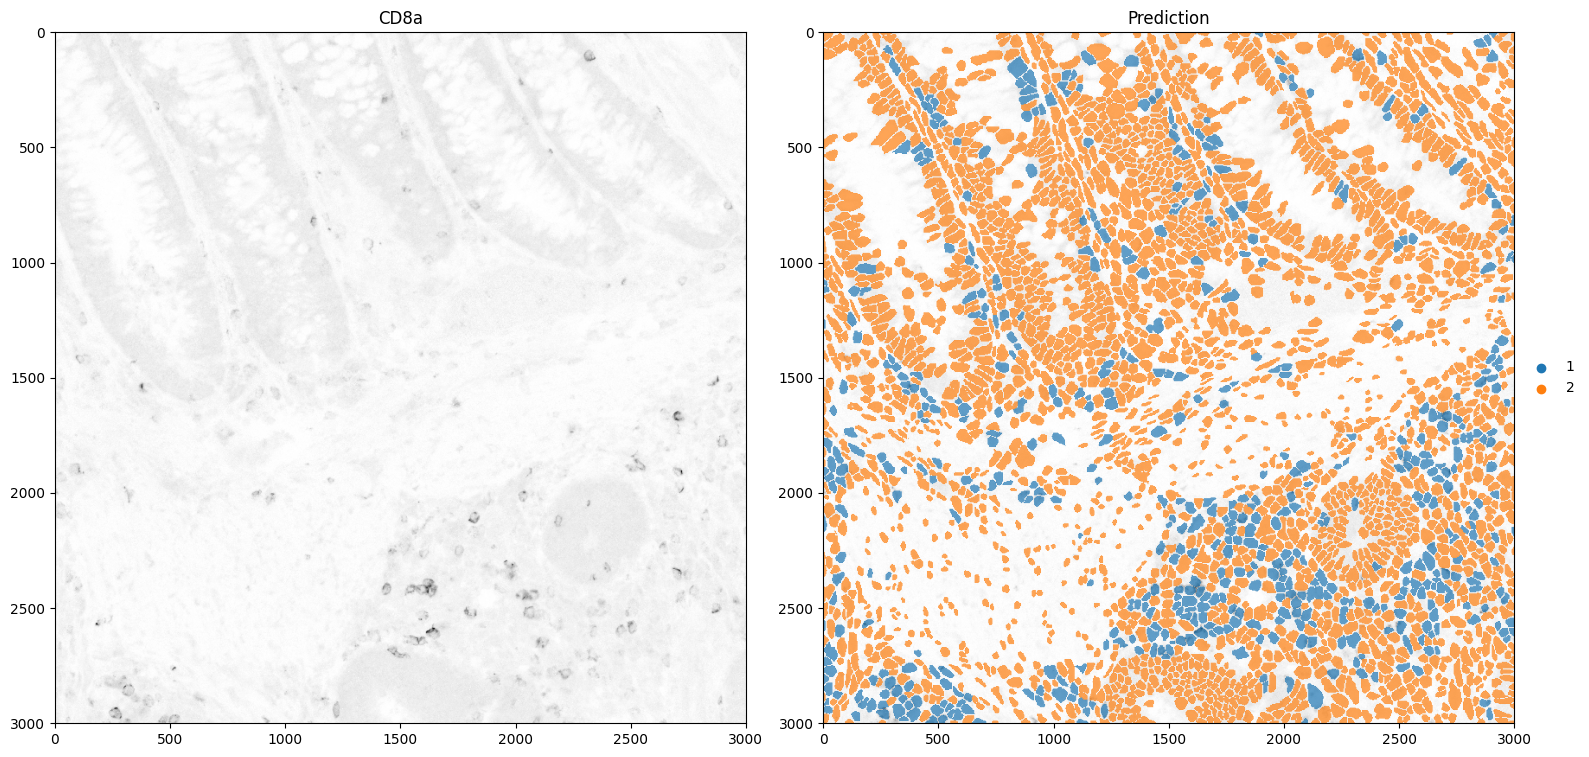

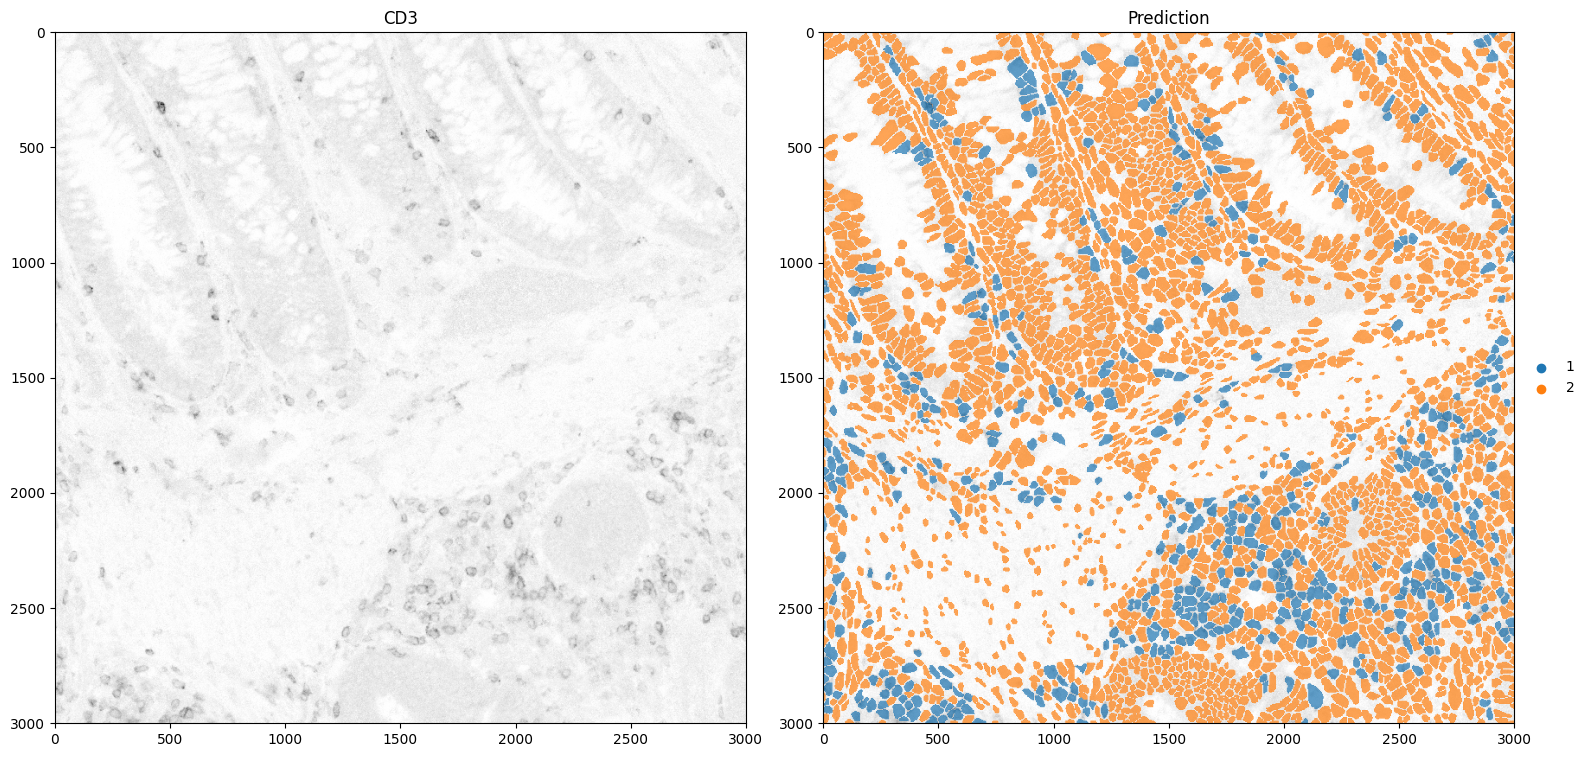

In [8]:
import harpy as hp
import matplotlib.pyplot as plt

for _channel in ["CD8a", "CD3"]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    _ = hp.pl.plot_sdata(
        sdata,
        image_name="REAscreen_IO_CRC",
        channel=_channel,
        to_coordinate_system="global_1",
        render_images_kwargs={"cmap": "binary"},
        show_kwargs={"title": _channel, "colorbar": False},
        ax=axes[0],
    )

    _ = hp.pl.plot_sdata(
        sdata,
        image_name="REAscreen_IO_CRC",
        channel=_channel,
        table_name="table_cells_z_scored_filterd",
        labels_name="labels_cells_instanseg",
        color="pred_class",
        to_coordinate_system="global_1",
        render_images_kwargs={"cmap": "binary"},
        render_labels_kwargs={
            "fill_alpha": 0.7,
            "outline_alpha": 0.2,
        },
        show_kwargs={"title": "Prediction", "colorbar": False},
        ax=axes[1],
    )

    plt.tight_layout()